
<h1 style="text-align: center;"><b>Kaggle competition. Journey to Springfield</b></h1>



Public Score - 0.99256 <br>
Place - #86


kaggle competitions leaderboard journey-to-springfield1 -d

(@misc{journey-to-springfield1,
    author = {dlschool},
    title = {Journey to Springfield},
    year = {2025},
    howpublished = {\url{https://kaggle.com/competitions/journey-to-springfield1}},
    note = {Kaggle}
})

#  Calculating ROC-AUC




In [ ]:
from sklearn.metrics import roc_auc_score

y_true = [
    0,
    1,
    1,
    0,
    1
]

y_predictions = [
    0.1,
    0.9,
    0.4,
    0.6,
    0.61
]

roc_auc_score(y_true, y_predictions)

np.float64(0.8333333333333333)

In [ ]:
!pip install catboost
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.2 MB/s eta 0:00:00


## Downloading data

In [ ]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 138MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 69.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 42.3MB/s]


In [ ]:
data = pd.read_csv('./train.csv')


In [ ]:

num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]


cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [ ]:
display(data.sample(5))

display(data.info())

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')


missing_table = data.isna().sum().reset_index()
missing_table.columns = ['column_name', 'num_missing']
print("Количество пропусков по колонкам:")
display(missing_table)


for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


print("После заполнения пропусков осталось NaN:", data.isna().sum().sum())


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
2649,22,26.25,605.9,Female,0,No,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
5106,53,20.80,1021.8,Female,0,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),1
1878,17,25.10,382.8,Male,0,No,No,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,No,Credit card (automatic),0
5180,71,92.00,6585.2,Male,1,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,No,No,One year,Yes,Electronic check,0
818,69,60.80,4263.4,Male,0,Yes,No,No,No phone service,DSL,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   float64
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

None

Количество пропусков по колонкам:


,column_name,num_missing
0,ClientPeriod,0
1,MonthlySpending,0
2,TotalSpent,0
3,Sex,0
4,IsSeniorCitizen,0
5,HasPartner,0
6,HasChild,0
7,HasPhoneService,0
8,HasMultiplePhoneNumbers,0
9,HasInternetService,0


После заполнения пропусков осталось NaN: 0
После заполнения пропусков:


np.int64(0)

## Analyzing data



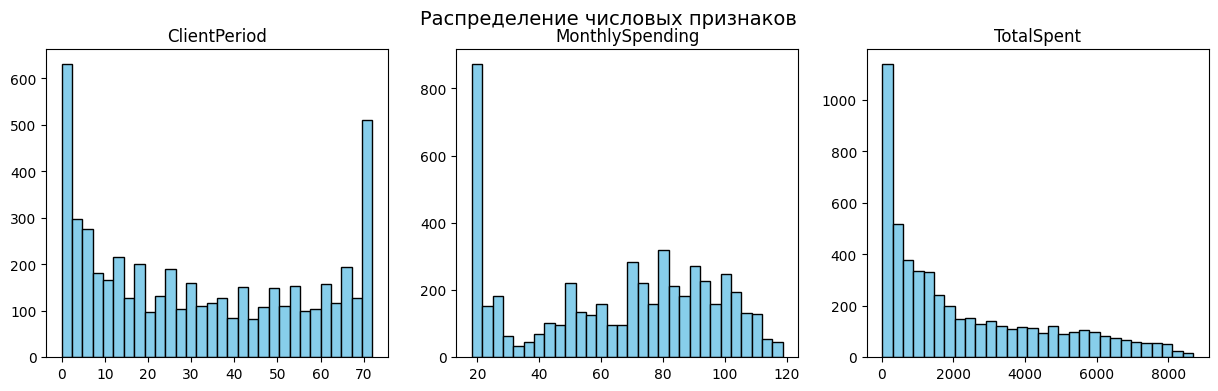

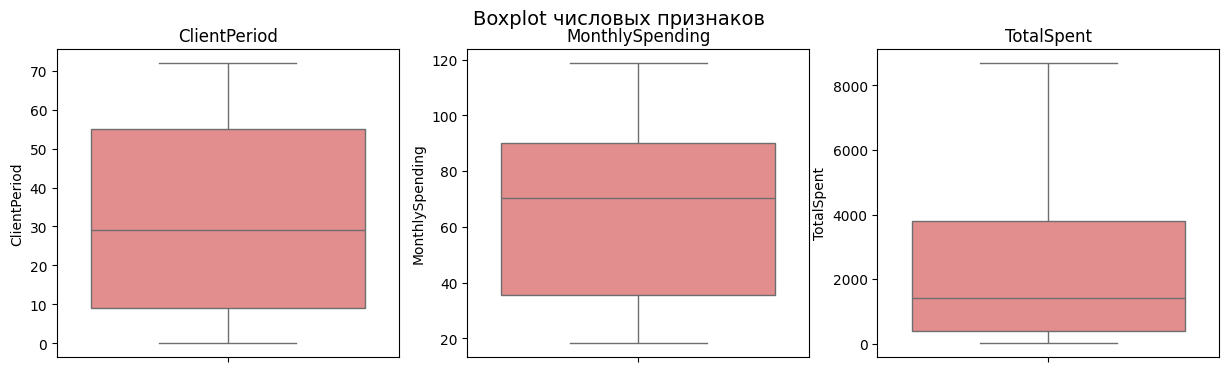

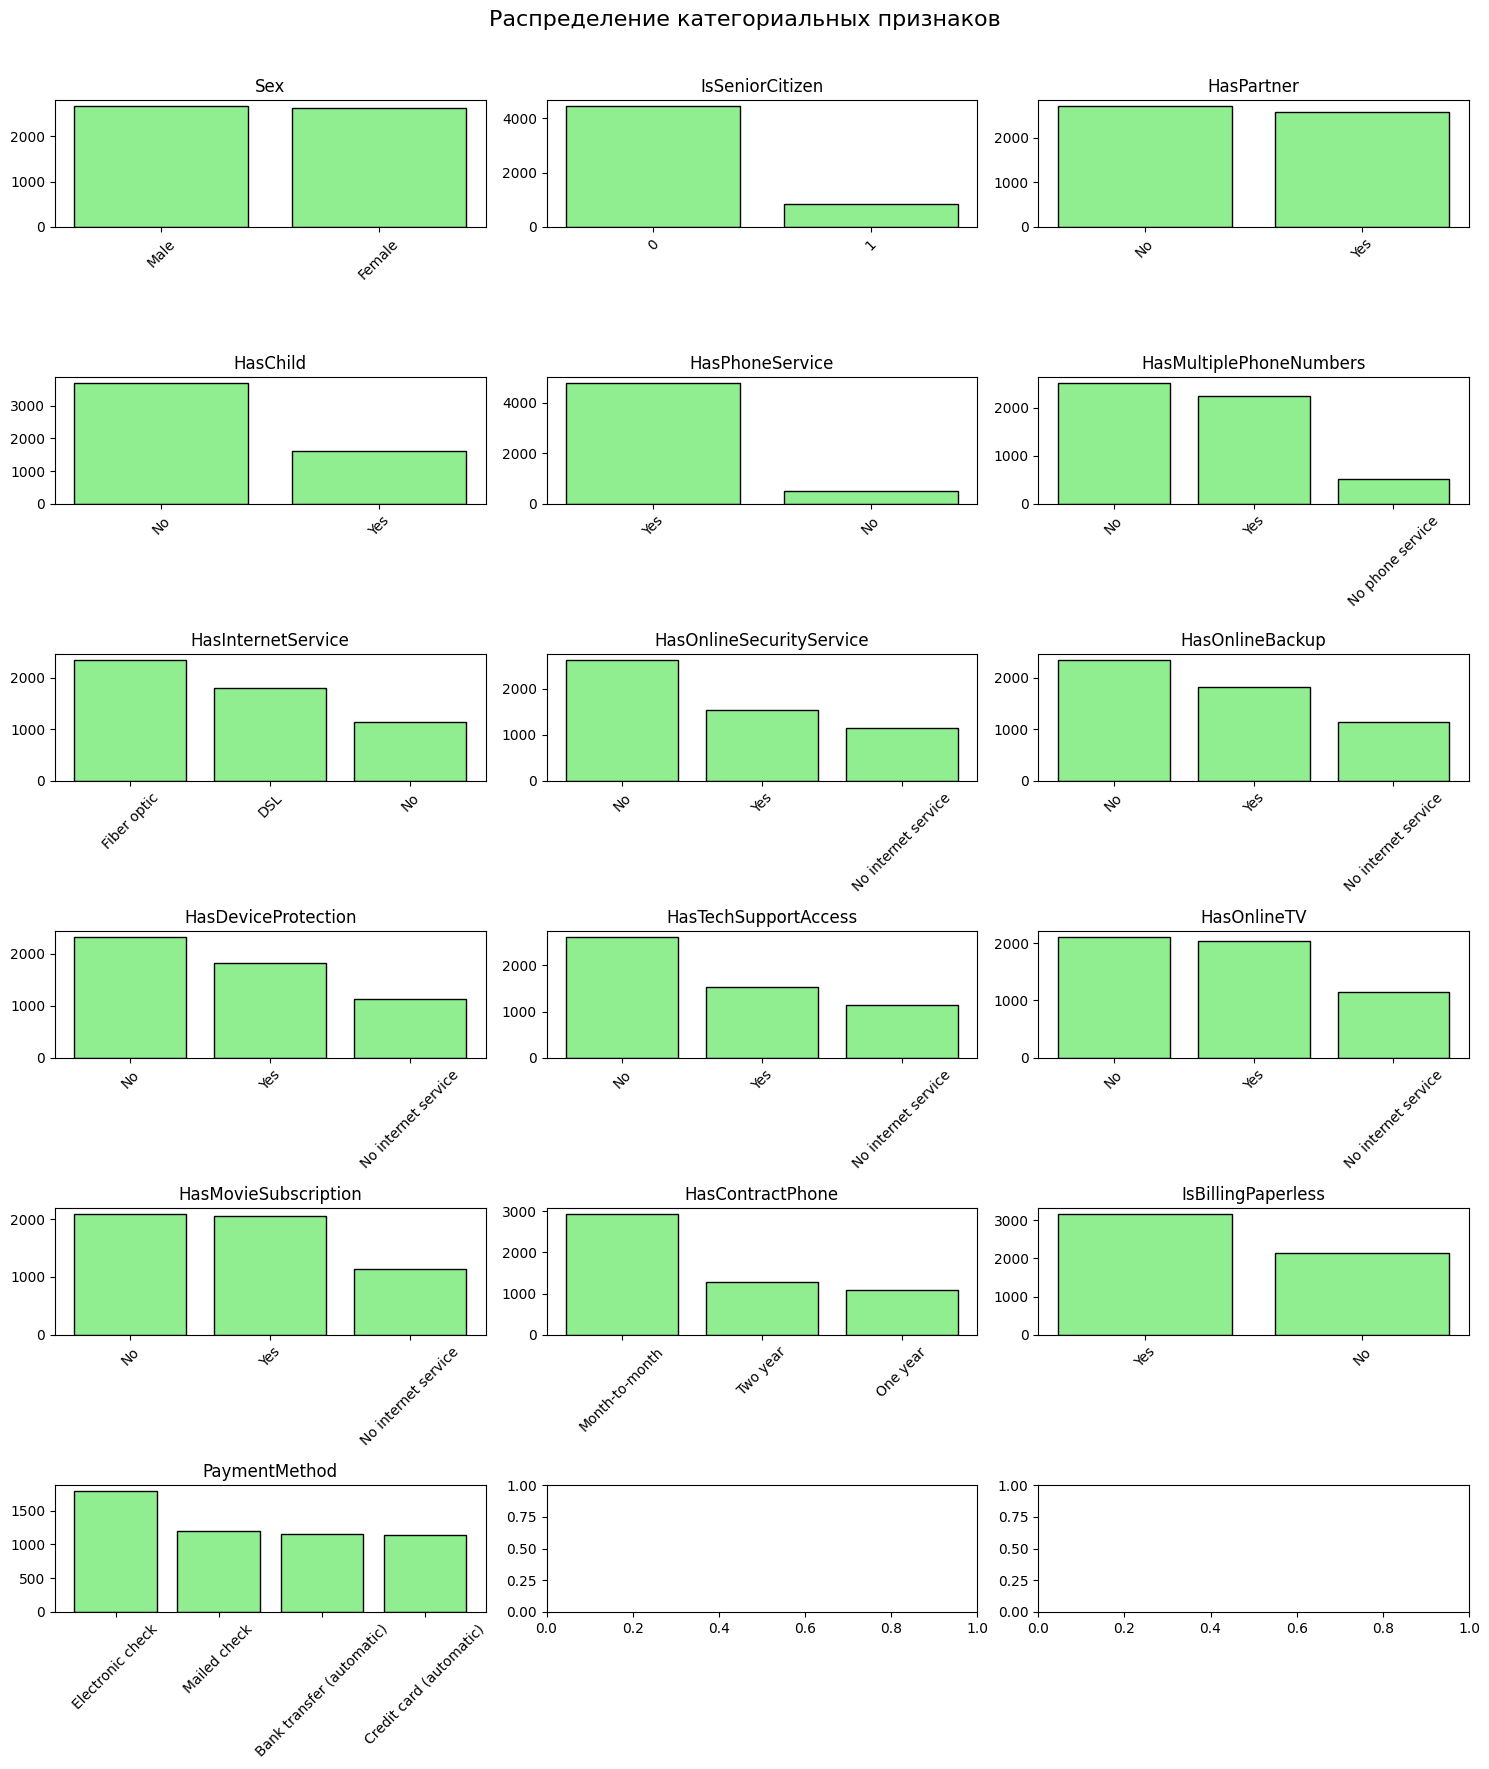

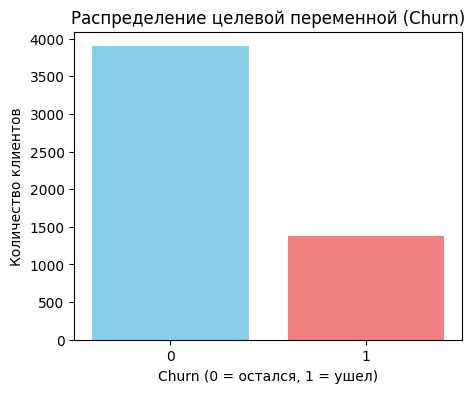

Распределение классов:
Churn
0    3898
1    1384
Name: count, dtype: int64

Доля класса 1 (ушедших клиентов): 26.20%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
plt.suptitle("Распределение числовых признаков", fontsize=14)
plt.show()

fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
plt.suptitle("Boxplot числовых признаков", fontsize=14)
plt.show()



fig, axes = plt.subplots(6, 3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    value_counts = data[col].value_counts()
    axes[i].bar(value_counts.index.astype(str), value_counts.values, color='lightgreen', edgecolor='black')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Распределение категориальных признаков", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



plt.figure(figsize=(5, 4))
churn_counts = data[target_col].value_counts()
plt.bar(churn_counts.index.astype(str), churn_counts.values, color=['skyblue', 'lightcoral'])
plt.title("Распределение целевой переменной (Churn)")
plt.xlabel("Churn (0 = остался, 1 = ушел)")
plt.ylabel("Количество клиентов")
plt.show()

print("Распределение классов:")
print(churn_counts)
print(f"\nДоля класса 1 (ушедших клиентов): {churn_counts[1] / churn_counts.sum():.2%}")


In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

In [ ]:
# --- 1. Разделим на фичи и целевую переменную
X = data[feature_cols]
y = data[target_col]

# --- 2. Разделим на train / valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Создаём трансформеры для числовых и категориальных признаков
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# --- 4. Объединяем их в один ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# --- 5. Создаём модель LogisticRegressionCV с подбором C по ROC-AUC
log_reg_cv = LogisticRegressionCV(
    Cs=[100, 10, 1, 0.1, 0.01, 0.001],
    cv=5,
    scoring='roc_auc',
    max_iter=500,
    refit=True,
    random_state=42
)

# --- 6. Собираем всё в единый pipeline
pipe = make_pipeline(preprocessor, log_reg_cv)

# --- 7. Обучаем модель
pipe.fit(X_train, y_train)

# --- 8. Предсказываем вероятности
y_valid_pred = pipe.predict_proba(X_valid)[:, 1]

# --- 9. Считаем ROC-AUC
roc_auc = roc_auc_score(y_valid, y_valid_pred)
print("ROC-AUC на валидации:", round(roc_auc, 4))

# --- 10. Лучший C:
best_C = pipe.named_steps['logisticregressioncv'].C_[0]
print("Лучший C:", best_C)

ROC-AUC на валидации: 0.8546
Лучший C: 1.0


Лучшее качество: 0.8546 (ROC-AUC).
Лучший параметр: C = 1.0

## Gradient Boosting



In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Разделение данных
X = data[feature_cols]
y = data[target_col]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Базовая модель
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_cols,
    verbose=0,
    random_seed=42
)

model.fit(X_train, y_train)

# Предсказания вероятностей
y_pred = model.predict_proba(X_valid)[:, 1]

# Оценка качества
roc_auc = roc_auc_score(y_valid, y_pred)
print("ROC-AUC на валидации:", roc_auc)

best_auc = 0
best_params = None

for lr in [0.1, 0.05, 0.01]:
    for iters in [200, 500, 800]:
        model = CatBoostClassifier(
            iterations=iters,
            learning_rate=lr,
            depth=6,
            cat_features=cat_cols,
            verbose=0,
            random_seed=42
        )
        model.fit(X_train, y_train)
        preds = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, preds)
        print(f"iters={iters}, lr={lr}, ROC-AUC={auc:.4f}")

        if auc > best_auc:
            best_auc = auc
            best_params = (iters, lr)

print(f"\nЛучшие параметры: iterations={best_params[0]}, learning_rate={best_params[1]}")
print(f"Лучший ROC-AUC: {best_auc:.4f}")


ROC-AUC на валидации: 0.8366541701379248
iters=200, lr=0.1, ROC-AUC=0.8505
iters=500, lr=0.1, ROC-AUC=0.8367
iters=800, lr=0.1, ROC-AUC=0.8261
iters=200, lr=0.05, ROC-AUC=0.8545
iters=500, lr=0.05, ROC-AUC=0.8488
iters=800, lr=0.05, ROC-AUC=0.8417
iters=200, lr=0.01, ROC-AUC=0.8534
iters=500, lr=0.01, ROC-AUC=0.8553
iters=800, lr=0.01, ROC-AUC=0.8560

Лучшие параметры: iterations=800, learning_rate=0.01
Лучший ROC-AUC: 0.8560


ROC-AUC на валидации: 0.8560

Параметры модели:

iterations = 800

learning_rate = 0.01

Остальные параметры — значения по умолчанию.

# Prediction

In [ ]:
# Лучшая модель из предыдущего шага (CatBoostClassifier)
best_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.01,
    cat_features=cat_cols,
    verbose=0,
    random_seed=42
)

# Обучаем модель на всём train-дейтафрейме
best_model.fit(data[feature_cols], data[target_col])

# Загружаем тестовые данные
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')

# Приводим числовые колонки к числовому типу (на случай строк)
for col in num_cols:
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Получаем предсказания вероятностей класса 1
submission['Churn'] = best_model.predict_proba(X_test[feature_cols])[:, 1]

# Сохраняем итоговый файл
submission.to_csv('./my_submission.csv', index=False)

print("Файл my_submission.csv успешно сохранён ✅")


from google.colab import files
files.download('my_submission.csv')

Файл my_submission.csv успешно сохранён ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>